Loaded 1024pi.out: angle=0.0°, Fx=3.217e+03, Fy=0.000e+00, components=x, n_points=51
maximum displacement (x): 27.13
sigma_noise added (x): 0.5426 (2.0% of maximum displacement)
realized experimental noise (x): 0.4318
sigma_noise prior: Exp(beta=0.3703)
Saved figure: c:\Users\paraj\Documents\bayesian_inference\examples\plots\data_vs_noise.pdf


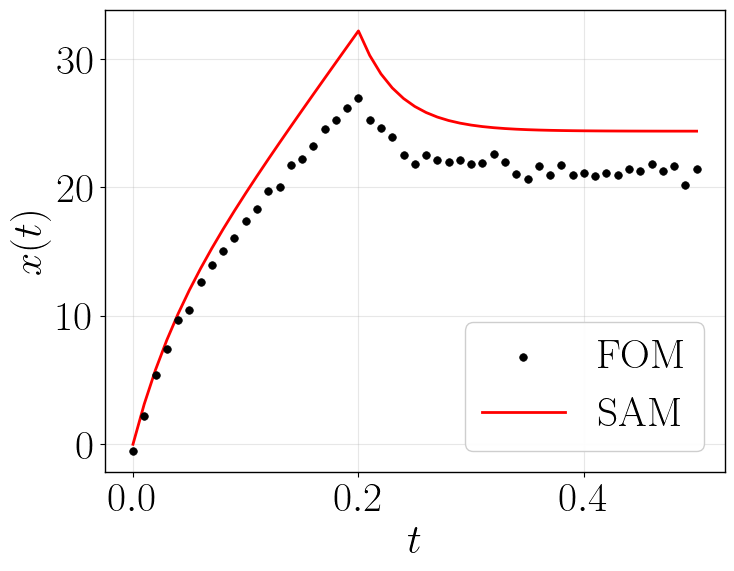

Saved figure: c:\Users\paraj\Documents\bayesian_inference\examples\plots\prior.pdf


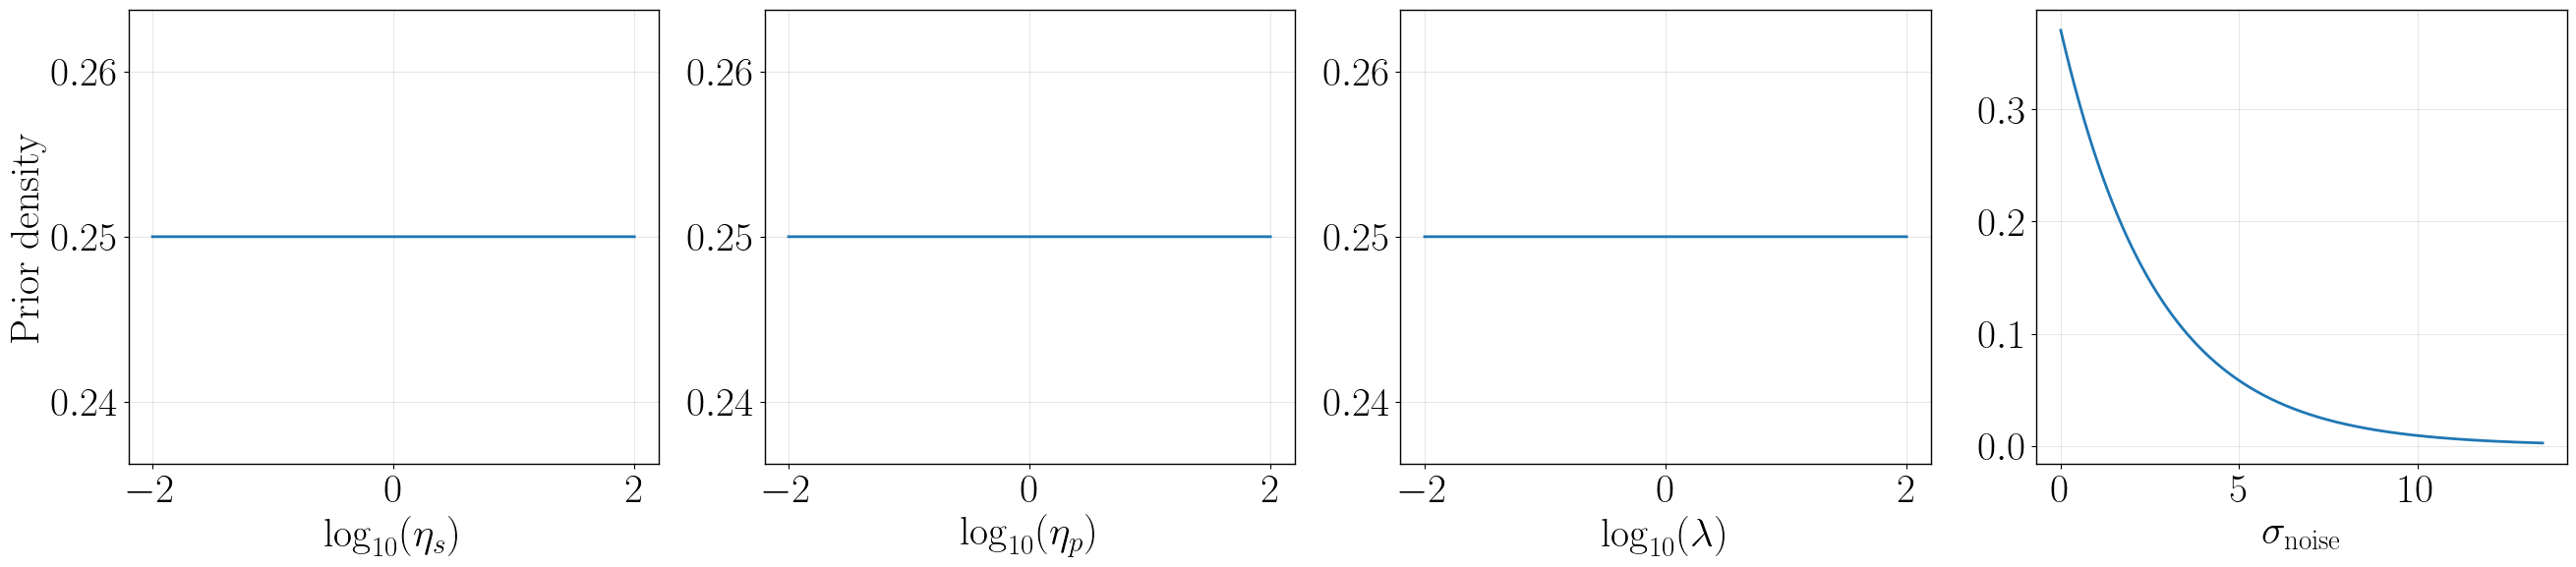


Preparing MCMC: ndim=4, walkers=8, steps=5000, init=kmeans, warmup=True

Initial walkers (physical):
  00: [0.09612634 0.30878089 0.07982503 1.10223501]
  01: [0.9081027  0.10098811 2.06419834 3.78933536]
  02: [ 0.21547243  1.10617351  2.23482241 11.35279871]
  03: [ 0.56797908 19.27734003  8.65081493  1.39209289]
  04: [1.62212169 1.08844876 1.0189562  7.2607893 ]
  05: [10.04818063  1.93714618  0.10913984  1.18837779]
  06: [ 1.2260811   0.12041638 11.42049542  1.16381438]
  07: [0.82254466 8.97938441 0.25638128 4.24907345]

Warm-up: 500 steps x 8 walkers


Warm-up:   0%|          | 0/500 [00:00<?, ?it/s]


Walkers after warm-up (physical):
  00: [0.51035534 1.16156286 0.080417   0.33777673]
  01: [0.46849903 1.19196106 0.08860599 0.49726289]
  02: [0.49067054 1.21900861 0.10286388 0.45038537]
  03: [0.4949655  1.06041598 0.0777042  0.47162167]
  04: [0.48672265 1.16226239 0.0835136  0.42263749]
  05: [0.52655123 1.03650296 0.06845773 0.52678076]
  06: [0.45936751 1.12970854 0.10320563 0.48418904]
  07: [0.49805301 0.92129178 0.09640801 0.52487606]


MCMC:   0%|          | 0/5000 [00:00<?, ?it/s]


MCMC Diagnostics Summary
Chains: 8  |  Samples/chain after burn-in: 3500  |  Total: 28000
----------------------------------------------------------------
Parameter                Mean            Std       Rhat
----------------------------------------------------------------
eta_s              5.0006e-01     2.3391e-02     1.0019
eta_p_eff          1.1007e+00     2.1871e-02     1.0030
lambda             8.8564e-02     3.2866e-03     1.0030
sigma_noise        4.8611e-01     5.1700e-02     1.0097
----------------------------------------------------------------
Mean Rhat                                        1.0044
Std Rhat                                         0.0031
----------------------------------------------------------------
Derived quantities
G                  1.2450e+01     6.3028e-01     1.0015
  G = eta_p_eff / lambda

All parameters show good convergence (Rhat <= 1.1)


Posterior-predictive adequacy (x, replicated data):
  Nominal central coverage of band:  95.0%
  ------

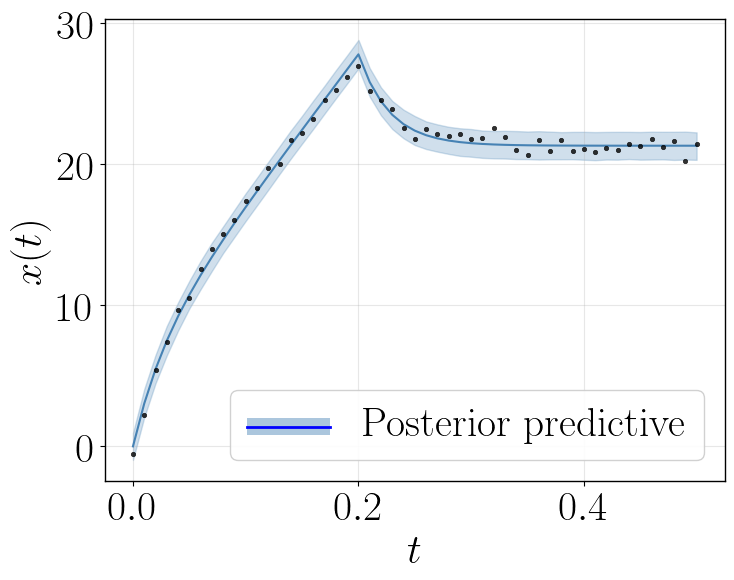

Saved figure: c:\Users\paraj\Documents\bayesian_inference\examples\plots\corner.pdf


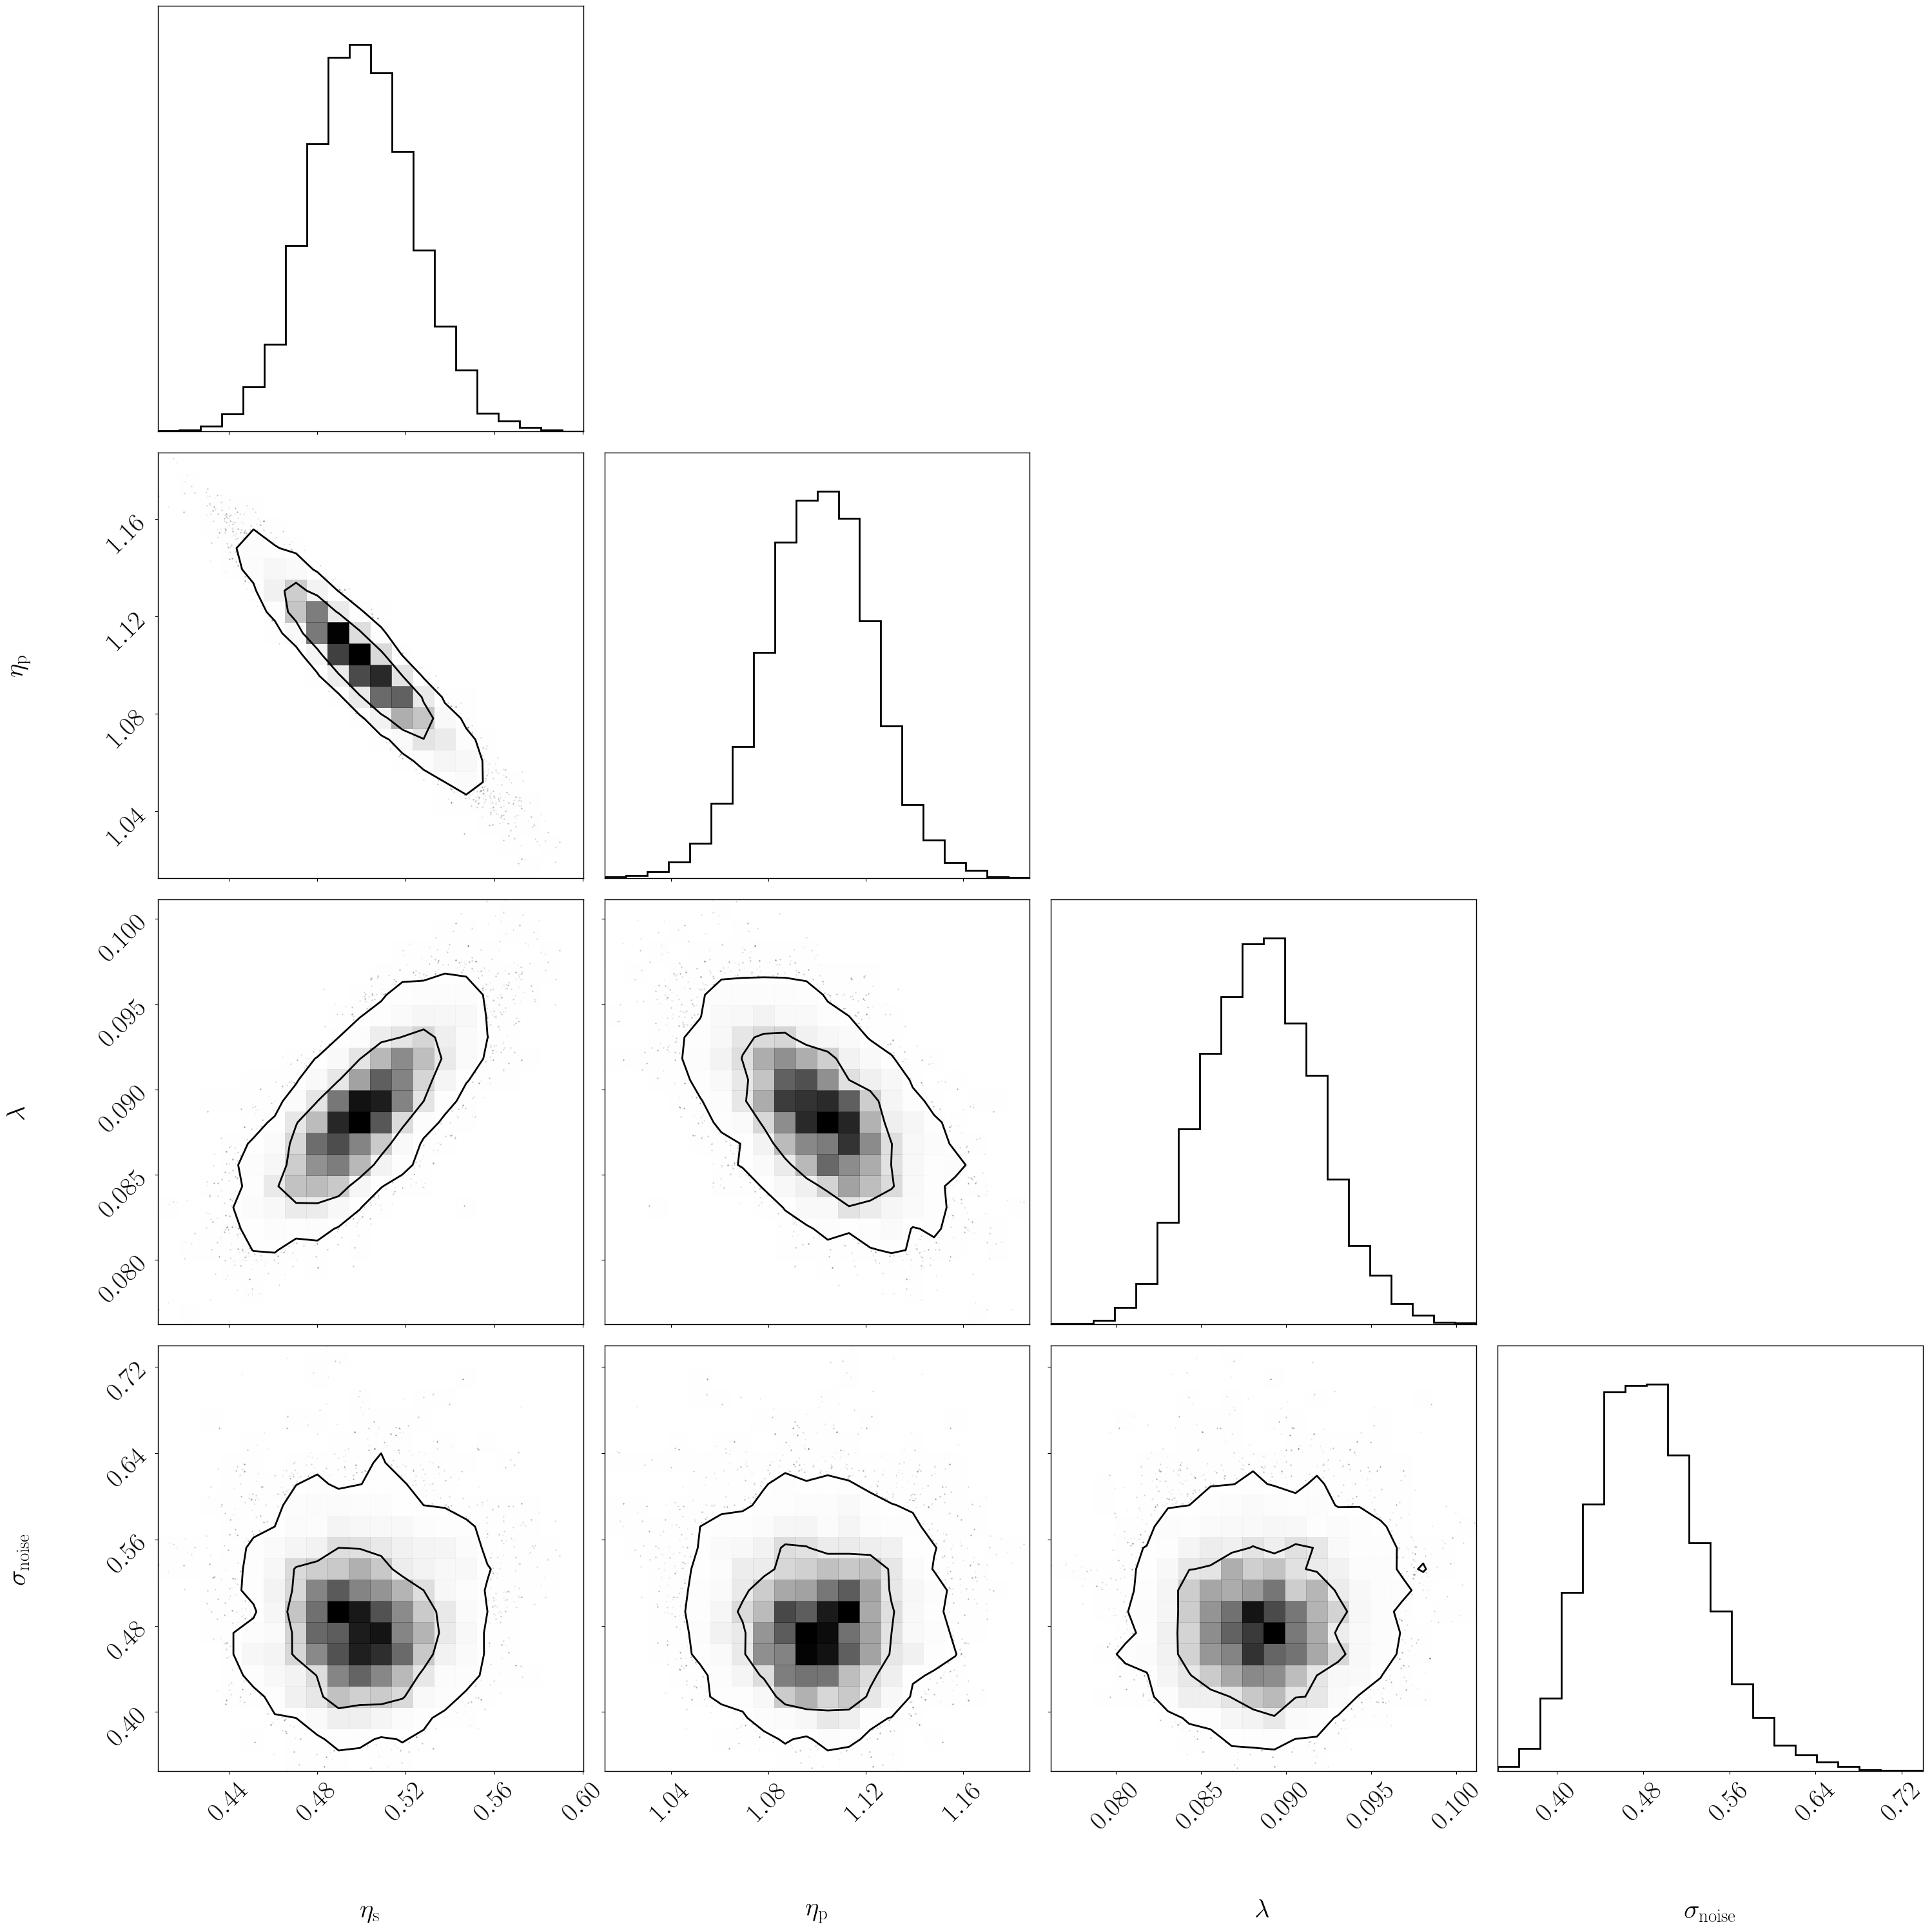

Saved figure: c:\Users\paraj\Documents\bayesian_inference\examples\plots\trace.pdf


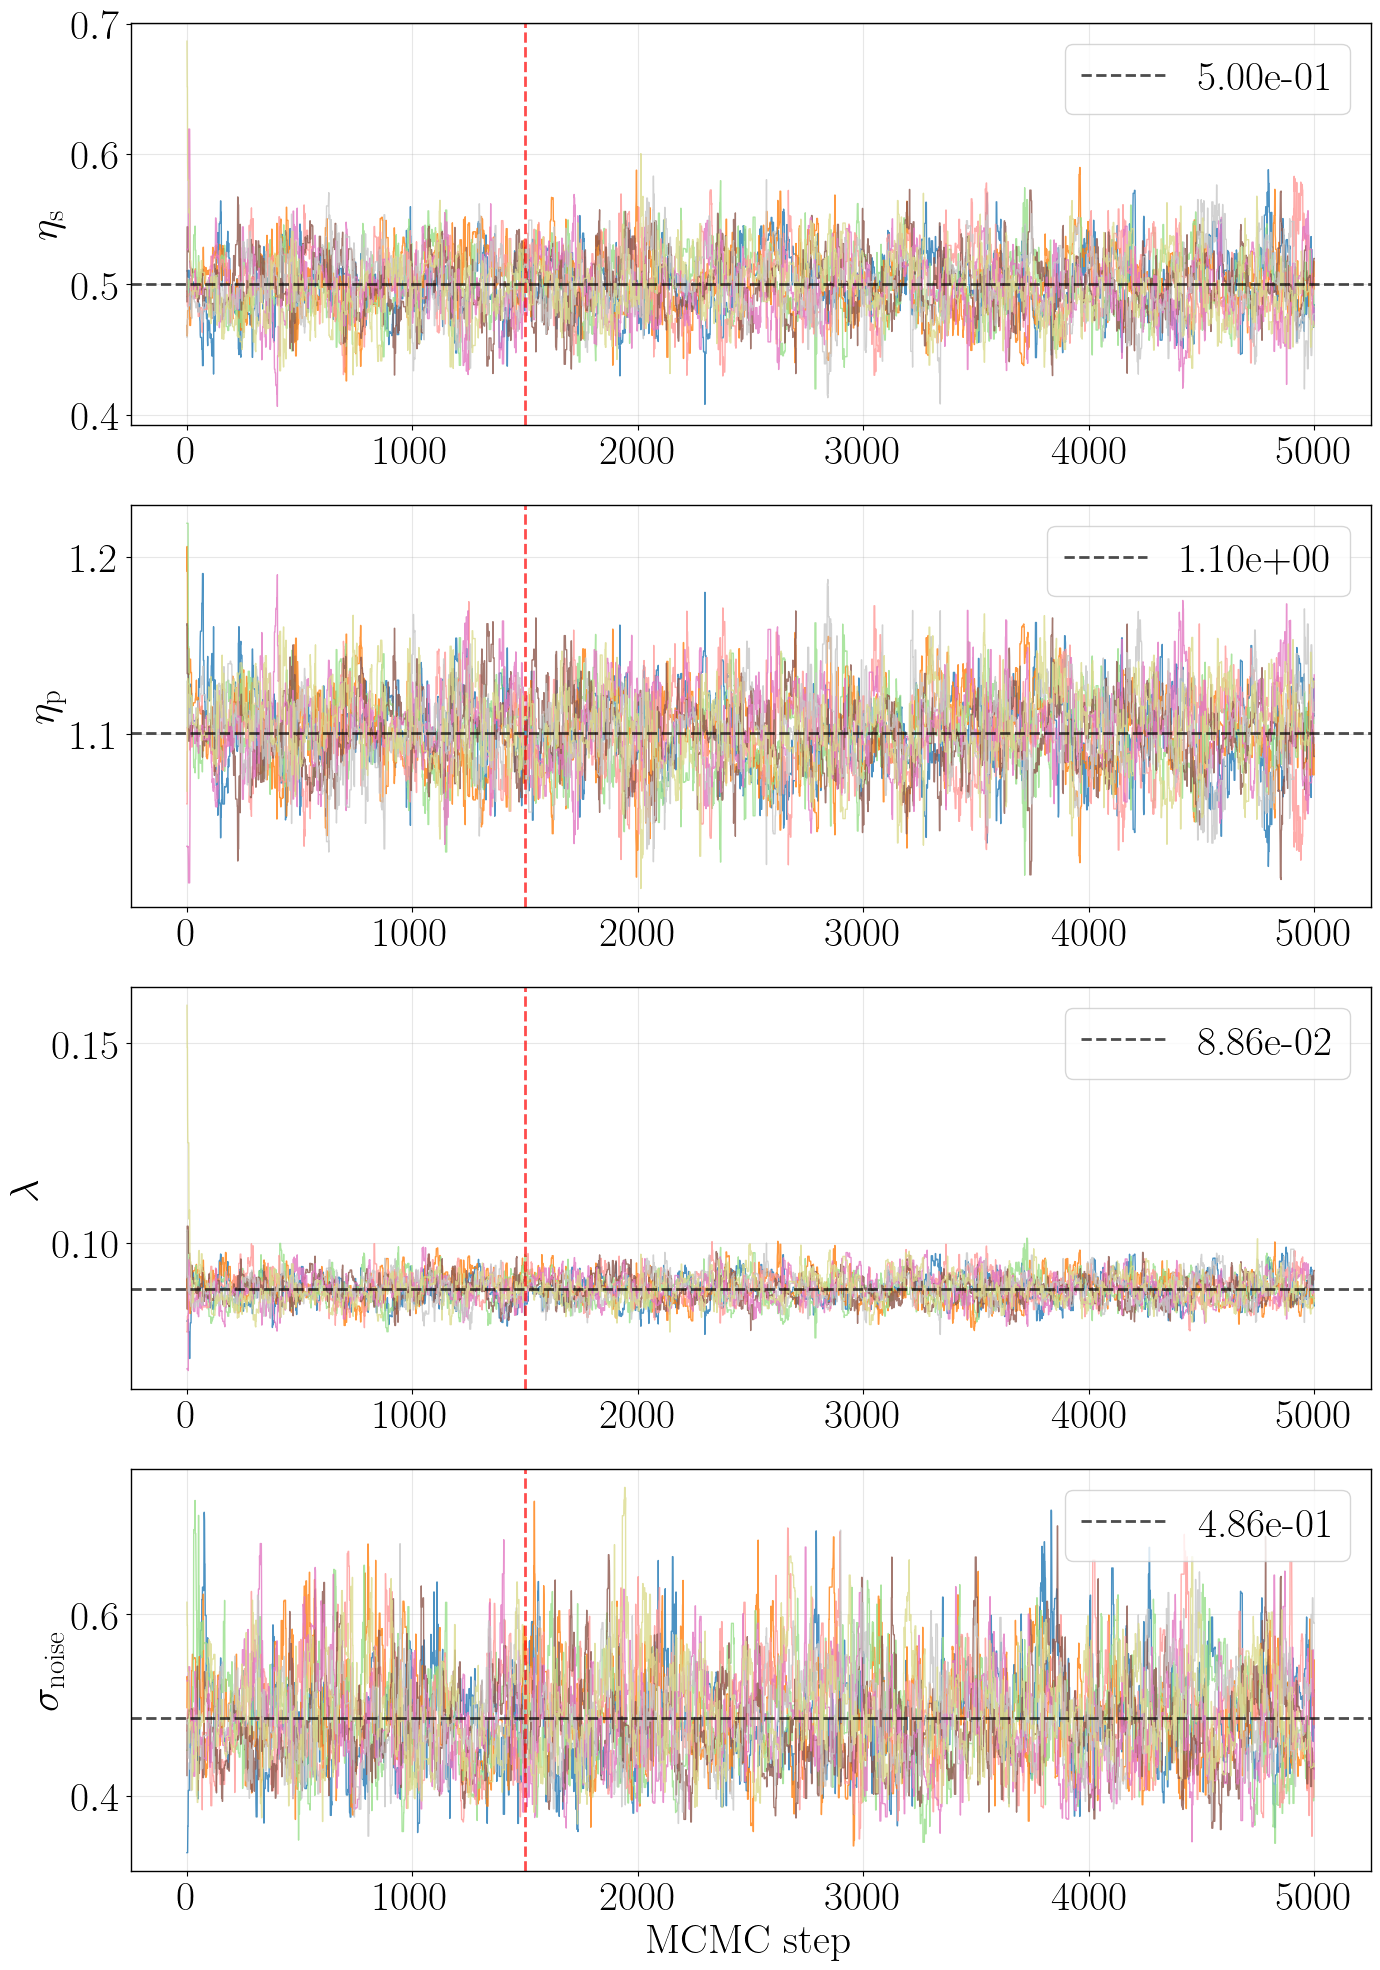

In [1]:
import numpy as np
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from packages.main import  InferenceProcedure

from packages.main import InferenceProcedure
import numpy as np

model = InferenceProcedure(
    force=1024*np.pi,
    material_model="viscoelastic",
    boundary_model="unbounded",
    theta=0,
    a=1.0,
    t_unload=0.2,
    sigma_noise_percent=2.0,
    sigma_bias = None,
    nsteps=5000,
    thin_factor=10)

model.load_data("data/nonlinear_viscoelastic/1024pi.out")
model.plot_data(theta_true=[0.5, 0.9, 0.1])
model.plot_prior()
model.run_mcmc(init_method="kmeans")
model.plot_results()